# Session 3 — Sequence-to-Sequence Learning

**PES University · NLP Course**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)

> **Runtime**: For Sections 6–8 (RNN training), set *Runtime → Change runtime type → GPU* before running.
> Files downloaded during this session (nietzsche.txt, spa.txt, etc.) live in `/content/` and are lost when the runtime resets — the cells re-download them automatically.

This notebook consolidates all Session 3 material into a single logical progression:

| Section | Topic |
|---|---|
| 1 | Web Scraping & Data Collection |
| 2 | Text Pre-processing Pipeline |
| 3 | POS Tagging & Named Entity Recognition |
| 4 | Sentiment Analysis |
| 5 | Seq2Seq Architecture — Theory |
| 6 | Character-level RNN Language Models |
| 7 | Seq2Seq Applications (Summarization & Translation) |
| 8 | Neural Machine Translation with Attention |
| 9 | Exercises |


---
<a id='s0'></a>
## 0. Environment Setup


**Note:** Installs Python packages that are absent on Google Colab (`afinn`, `newsapi-python`, `textblob`, `gensim`) then imports the standard data-science stack used throughout the notebook. Running all installs in one place at the top avoids mid-notebook interruptions and makes dependencies explicit.

*Key libraries:* `requests`/`BeautifulSoup` for web scraping, `pandas`/`numpy` for data manipulation, `matplotlib`/`seaborn` for visualisation. `%matplotlib inline` tells Jupyter to render plots inside the notebook output rather than opening a window.

In [1]:
import sys, subprocess

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# Packages not pre-installed on Colab — safe no-ops when already present
for _pkg in ['afinn', 'newsapi-python', 'textblob', 'gensim']:
    install(_pkg)

# Core
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, time, unicodedata, warnings

warnings.filterwarnings('ignore')
%matplotlib inline
print('Core imports OK')


Core imports OK


**Note:** Downloads the NLTK data packages needed later in the notebook. `stopwords` and `punkt`/`punkt_tab` are required by the tokeniser and stopword remover. `averaged_perceptron_tagger_eng` (introduced in NLTK ≥ 3.9) is needed by `pos_tag`. `vader_lexicon` powers the VADER sentiment analyser in the exercises.

*Why download here:* NLTK separates its code (pip package) from its data (separate download). Downloading everything in one cell prevents `LookupError` surprises in later cells.

In [2]:
import nltk
for pkg in ['stopwords', 'punkt', 'punkt_tab', 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng',
            'maxent_treebank_pos_tagger', 'vader_lexicon']:
    nltk.download(pkg, quiet=True)
print('NLTK downloads OK')


NLTK downloads OK


**Note:** Imports PyTorch and its key submodules — `nn` for building neural network layers, `F` for stateless functions (softmax, relu), `optim` for optimisers, and `DataLoader`/`TensorDataset` for batching.

`device` auto-selects the GPU if one is available (on Colab this is typically an NVIDIA T4) and falls back to CPU otherwise. Every model and tensor in later sections is moved to this device so computation happens on the fastest available hardware. *Tip: on Colab, set Runtime → Change runtime type → GPU before running this cell.*

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}  device: {device}')


PyTorch: 2.12.1+cpu  device: cpu


---
<a id='s1'></a>
## 1. Data Collection — Web Scraping

Collecting labelled text data from the web is the first step in most NLP pipelines. We cover three approaches: static HTML parsing, a REST news API, and a production scraping pipeline for NDTV.


### 1.1 BeautifulSoup — Wikipedia Table Scraping


**Note:** Sends an HTTP GET request to the Wikipedia COVID-19 statistics page and parses the HTML response with BeautifulSoup. The custom `User-Agent` header identifies our scraper politely so the server knows this is an educational tool rather than a malicious bot.

`BeautifulSoup(resp.content, 'html.parser')` converts the raw bytes into a tree of Python objects that we can navigate with CSS-like selectors (`find`, `find_all`, etc.).

In [4]:
url = 'https://en.wikipedia.org/wiki/COVID-19_pandemic_by_country_and_territory'
headers = {'User-Agent': 'NLP-Course/1.0 (educational)'}
resp = requests.get(url, headers=headers, timeout=15)

soup = BeautifulSoup(resp.content, 'html.parser')
print('Title:', soup.title.string)
print('Status:', resp.status_code)


Title: COVID-19 pandemic by country and territory - Wikipedia
Status: 200


**Note:** Demonstrates the simplest BeautifulSoup pattern — `find_all('a')` returns every `<a>` anchor tag on the page as a list. We then extract the `href` attribute from each tag to get the link targets. A real Wikipedia article typically has thousands of cross-links.

In [5]:
# Extract all <a> hyperlinks from the page
all_links = soup.find_all('a')
print(f'Total links: {len(all_links)}')
print('First 5:', [a.get('href') for a in all_links[:5]])


Total links: 4130
First 5: ['#bodyContent', '/wiki/Main_Page', '/wiki/Wikipedia:Contents', '/wiki/Portal:Current_events', '/wiki/Special:Random']


**Note:** Locates the first `wikitable` on the page, extracts its header row and first five data rows, and loads them into a pandas DataFrame. `find_all(['th', 'td'])` handles tables that mix `<th>` and `<td>` in the header row (common in Wikipedia). The `try/except` guards against column-count mismatches caused by Wikipedia's evolving table structure.

In [6]:
# Find a specific table (class='wikitable sortable')
table = soup.find('table', class_='wikitable')
if table:
    rows = table.find_all('tr')
    print(f'Table rows: {len(rows)}')
    headers_row = [th.get_text(strip=True) for th in rows[0].find_all(['th', 'td'])]
    print('Columns:', headers_row[:6])
    data_rows = []
    for row in rows[1:6]:
        cols = [td.get_text(strip=True) for td in row.find_all('td')]
        if cols:
            data_rows.append(cols)
    if data_rows:
        n_cols = len(data_rows[0])
        col_names = headers_row[:n_cols] if len(headers_row) >= n_cols else None
        try:
            print(pd.DataFrame(data_rows, columns=col_names))
        except Exception as e:
            print(f'DataFrame error: {e}')
            print(data_rows[:2])
else:
    print('No wikitable found — page structure may have changed')


Table rows: 3
Columns: ['Map oftotal confirmed casesby country[10][note 2][note 3]']
  Map oftotal confirmed casesby country[10][note 2][note 3]
0                                                          
1         Date of latest upload at theCommons source       


### 1.2 News API

The [NewsAPI](https://newsapi.org) provides structured access to thousands of news sources via a REST endpoint. Useful when you need clean, labelled article data without HTML parsing.


**Note:** Demonstrates the `newsapi-python` client interface. The actual API calls are commented out (an API key from newsapi.org is required), but the print block documents the three main endpoints: `get_top_headlines`, `get_everything`, and `get_sources`. NewsAPI returns clean JSON that maps directly to a pandas DataFrame, making it easier to work with than raw HTML scraping.

In [7]:
# pip install newsapi-python
try:
    from newsapi import NewsApiClient
except ImportError:
    install('newsapi-python')
    from newsapi import NewsApiClient

# NOTE: replace with your own key from newsapi.org
# newsapi = NewsApiClient(api_key='YOUR_KEY')

# Pattern for top headlines
print("""
Usage:
    newsapi = NewsApiClient(api_key='...')

    # Top headlines
    top = newsapi.get_top_headlines(q='AI', language='en', country='in')

    # Everything (broader search)
    everything = newsapi.get_everything(q='NLP', language='en', page_size=20)

    # Available sources
    sources = newsapi.get_sources(language='en', country='in')

    # Convert to DataFrame
    articles = pd.DataFrame(everything['articles'])
""")



Usage:
    newsapi = NewsApiClient(api_key='...')

    # Top headlines
    top = newsapi.get_top_headlines(q='AI', language='en', country='in')

    # Everything (broader search)
    everything = newsapi.get_everything(q='NLP', language='en', page_size=20)

    # Available sources
    sources = newsapi.get_sources(language='en', country='in')

    # Convert to DataFrame
    articles = pd.DataFrame(everything['articles'])



### 1.3 NDTV News Scraping Pipeline

A production-style scraper that pulls news headlines, articles, and categories from multiple NDTV sections and assembles a labelled `DataFrame`.


**Note:** Defines `scrape_ndtv()`, a resilient scraper that tries multiple CSS selector patterns to handle NDTV's evolving HTML structure. `build_news_dataset()` calls it across several category URLs and assembles the results into a labelled DataFrame. If live scraping returns nothing (NDTV may block automated requests), `FALLBACK_NEWS` provides ten hand-written sample articles so all downstream cells continue to run.

In [8]:
def scrape_ndtv(url: str) -> list:
    """Scrape news headlines and articles from one NDTV category URL."""
    category = url.split('/')[-1]
    try:
        resp = requests.get(url, timeout=15,
                            headers={'User-Agent': 'NLP-Course/1.0 (educational)'})
        soup = BeautifulSoup(resp.content, 'html.parser')

        # Try multiple CSS selector patterns across NDTV redesigns
        headlines = (soup.find_all('h2', class_='nstory_header') or
                     soup.find_all('h2', class_='news_Hed') or
                     soup.find_all('div', class_='news_Hed') or
                     soup.select('article h2') or
                     soup.select('div.news-card h3'))
        intros = (soup.find_all('div', class_='nstory_intro') or
                  soup.find_all('p', class_='news_intro') or
                  soup.select('article p') or
                  soup.select('div.news-card p'))

        articles = []
        for h, a in zip(headlines, intros):
            link = h.find('a')
            articles.append({
                'news_headline': (link['title'] if link and link.get('title') else h.get_text(strip=True)),
                'news_article':  a.get_text(strip=True),
                'news_category': category,
            })
        return articles
    except Exception as e:
        print(f'Error scraping {url}: {e}')
        return []


# Fallback sample data (used when scraping yields 0 articles)
FALLBACK_NEWS = [
    {'news_headline': 'India launches new space mission', 'news_article': 'India successfully launched its latest space mission today marking a new milestone in the country national space programme.', 'news_category': 'india'},
    {'news_headline': 'Budget session begins in Parliament', 'news_article': 'The winter session of Parliament commenced today with both houses set to discuss key bills including economic reforms.', 'news_category': 'india'},
    {'news_headline': 'Global climate summit reaches agreement', 'news_article': 'World leaders gathered in Geneva have reached a landmark agreement on carbon emissions reduction targets for the next decade.', 'news_category': 'world-news'},
    {'news_headline': 'US China trade talks progress', 'news_article': 'Senior officials from the United States and China met in Washington to discuss trade barriers and intellectual property rights.', 'news_category': 'world-news'},
    {'news_headline': 'Mumbai metro expansion complete', 'news_article': 'The new metro line connecting the western suburbs of Mumbai has opened to commuters ahead of schedule and under budget.', 'news_category': 'cities'},
    {'news_headline': 'Bengaluru water crisis deepens', 'news_article': 'Authorities in Bengaluru have declared a water emergency after reservoir levels dropped to a five-year low due to poor monsoon.', 'news_category': 'cities'},
    {'news_headline': 'New education policy rolled out', 'news_article': 'The Ministry of Education announced the phased rollout of the National Education Policy 2020 across all states from next semester.', 'news_category': 'india'},
    {'news_headline': 'Europe sees record temperatures', 'news_article': 'Several European cities recorded their highest ever winter temperatures this week raising fresh concerns about climate change impacts.', 'news_category': 'world-news'},
    {'news_headline': 'Chennai airport expansion approved', 'news_article': 'The government has approved a major expansion of Chennai international airport that will double its passenger handling capacity.', 'news_category': 'cities'},
    {'news_headline': 'Agricultural reforms benefit farmers', 'news_article': 'New direct benefit transfer schemes have helped over two million farmers access credit for the upcoming rabi cropping season.', 'news_category': 'india'},
]

def build_news_dataset(urls: list) -> pd.DataFrame:
    """Scrape multiple NDTV URLs; fall back to sample data if scraping fails."""
    all_articles = []
    for url in urls:
        all_articles.extend(scrape_ndtv(url))
        time.sleep(1)  # polite delay

    if not all_articles:
        print('WARNING: live scraping returned 0 articles (NDTV HTML changed).')
        print('Using fallback sample dataset for demonstration.')
        return pd.DataFrame(FALLBACK_NEWS)[['news_headline', 'news_article', 'news_category']]

    df = pd.DataFrame(all_articles)
    return df[['news_headline', 'news_article', 'news_category']]


ndtv_urls = [
    'https://www.ndtv.com/india',
    'https://www.ndtv.com/world-news',
    'https://www.ndtv.com/cities',
]

news_df = build_news_dataset(ndtv_urls)
print(news_df.shape)
print(news_df['news_category'].value_counts())
news_df.head(3)


Using fallback sample dataset for demonstration.
(10, 3)
news_category
india         4
world-news    3
cities        3
Name: count, dtype: int64


,news_headline,news_article,news_category
0,India launches new space mission,India successfully launched its latest space m...,india
1,Budget session begins in Parliament,The winter session of Parliament commenced tod...,india
2,Global climate summit reaches agreement,World leaders gathered in Geneva have reached ...,world-news


**Note:** Saves the scraped DataFrame to `news.csv` on disk. This persistence step decouples the expensive scraping step (Section 1) from the processing steps (Sections 2–4): later cells can simply call `pd.read_csv('news.csv')` without re-scraping. On Colab the file lives at `/content/news.csv` and is lost when the runtime resets, but the Section 1 cells regenerate it automatically.

In [ ]:
# Save for reuse across sections
news_df.to_csv('news.csv', index=False, encoding='utf-8')
print('Saved news.csv')


Saved news.csv


<div style="background:#fff8e1;border-left:5px solid #f9a825;padding:10px 14px;border-radius:4px;margin:6px 0"><b>Ethical Scraping</b><br/>
Always check <code>robots.txt</code>, set a descriptive <code>User-Agent</code>, add <code>time.sleep()</code> delays between requests, and never scrape login-protected or paywalled content without permission.
</div>


---
<a id='s2'></a>
## 2. Text Pre-processing Pipeline

Raw news text contains HTML markup, accented characters, special symbols, inflected words, and stopwords. We build a reusable `normalize_corpus()` pipeline from individual steps.


**Note:** Loads the spaCy `en_core_web_sm` model (73 MB), which provides tokenisation, POS tagging, lemmatisation, and NER in a single pipeline. The `try/except` block auto-downloads the model if it is missing — this runs transparently on both local machines and Colab. The stopword list deliberately preserves *"no"* and *"not"* because stripping them would reverse the polarity of negated phrases like *"not good"*.

In [ ]:
import spacy
import nltk
from nltk.tokenize.toktok import ToktokTokenizer
from nltk.stem.porter import PorterStemmer

try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm', '-q'])
    nlp = spacy.load('en_core_web_sm')

tokenizer     = ToktokTokenizer()
stopword_list = nltk.corpus.stopwords.words('english')
# Preserve negation words — critical for sentiment tasks
for w in ['no', 'not']:
    if w in stopword_list:
        stopword_list.remove(w)

print('spaCy model loaded, stopwords ready')


spaCy model loaded, stopwords ready


### 2.1 Strip HTML Tags


**Note:** Defines `strip_html_tags()`, which uses BeautifulSoup's `.get_text()` method to remove all HTML markup. This is safer than a regex approach (`re.sub(r'<.*?>', '', text)`) because BeautifulSoup correctly handles malformed HTML, multi-line tags, HTML comments, and script/style blocks that a simple regex would miss.

In [ ]:
def strip_html_tags(text: str) -> str:
    return BeautifulSoup(text, 'html.parser').get_text()

strip_html_tags('<html><h2>Some <b>important</b> text</h2></html>')


'Some important text'

### 2.2 Remove Accented Characters


**Note:** Defines `remove_accented_chars()` using Unicode normalisation. `unicodedata.normalize('NFKD', text)` decomposes each accented character into its base letter plus a combining diacritic mark (e.g., *é* → *e* + *◌́*). Encoding to ASCII with `errors='ignore'` then drops the combining marks, producing plain ASCII text. NFKD also collapses ligatures (ﬁ → fi) and compatibility forms.

In [ ]:
def remove_accented_chars(text: str) -> str:
    return (
        unicodedata.normalize('NFKD', text)
        .encode('ascii', 'ignore')
        .decode('utf-8', 'ignore')
    )

remove_accented_chars('Sómě Áccěntěd těxt — café résumé')


'Some Accented text  cafe resume'

### 2.3 Remove Special Characters


**Note:** Defines `remove_special_characters()`, which strips everything outside `[a-zA-Z0-9\s]` using a regex character class. The `remove_digits` flag toggles whether digits are kept: for factual or numerical text keep them; for topic modelling (where "2023" is noise) remove them. The function is called at the end of the normalisation pipeline.

In [ ]:
def remove_special_characters(text: str, remove_digits: bool = False) -> str:
    pattern = r'[^a-zA-Z0-9\s]' if not remove_digits else r'[^a-zA-Z\s]'
    return re.sub(pattern, '', text)

print(remove_special_characters('Well this was fun! What do you think? 123#@!', remove_digits=False))
print(remove_special_characters('Well this was fun! What do you think? 123#@!', remove_digits=True))


Well this was fun What do you think 123
Well this was fun What do you think 


### 2.4 Text Lemmatization (spaCy)

Lemmatization maps inflected word forms to their canonical base form using grammatical rules — `crashing` → `crash`, `was` → `be`. Unlike stemming it always produces real words.


**Note:** Defines `lemmatize_text()` using spaCy's morphological lemmatiser. Unlike stemming, lemmatisation maps to real dictionary words: *"crashing"* → *"crash"*, *"was"* → *"be"*. The `-PRON-` guard preserves pronouns in their original form; in newer spaCy versions this token has been replaced by the actual lemma, so the guard is backward-compatible.

In [ ]:
def lemmatize_text(text: str) -> str:
    doc = nlp(text)
    return ' '.join(
        token.lemma_ if token.lemma_ != '-PRON-' else token.text
        for token in doc
    )

print(lemmatize_text('My system keeps crashing! His crashed yesterday, ours crashes daily.'))


my system keep crash ! his crash yesterday , our crash daily .


### 2.5 Text Stemming (NLTK PorterStemmer)

Stemming is faster but cruder — it strips suffixes heuristically, producing stems that may not be real words (`studies` → `studi`). Use for keyword search, not generation.


**Note:** Defines `simple_stemmer()` using NLTK's Porter stemmer, which applies a fixed sequence of suffix-stripping rules without a dictionary. Stemming is faster than lemmatisation (O(word_length) vs. a pipeline lookup) but produces non-words: *"studies"* → *"studi"*. Use stemming for information-retrieval tasks where speed and recall matter more than readability.

In [ ]:
def simple_stemmer(text: str) -> str:
    ps = PorterStemmer()
    return ' '.join(ps.stem(word) for word in text.split())

print(simple_stemmer('My system keeps crashing his crashed yesterday, ours crashes daily'))


my system keep crash hi crash yesterday, our crash daili


### 2.6 Remove Stopwords


**Note:** Defines `remove_stopwords()`, which first tokenises the text with NLTK's `ToktokTokenizer` (handles contractions and punctuation better than `str.split()`), then filters each token against the stopword list. The `is_lower_case` flag synchronises case-folding with the all-lowercase stopword list to avoid missing stopwords like *"The"* or *"Is"*.

In [ ]:
def remove_stopwords(text: str, is_lower_case: bool = False) -> str:
    tokens = tokenizer.tokenize(text)
    tokens = [t.strip() for t in tokens]
    if is_lower_case:
        filtered = [t for t in tokens if t not in stopword_list]
    else:
        filtered = [t for t in tokens if t.lower() not in stopword_list]
    return ' '.join(filtered)

print(remove_stopwords('The, and, if are stopwords, but computer is not a stopword'))


, , stopwords , computer not stopword


### 2.7 Full Pipeline — `normalize_corpus()`

Composes all steps into a single function. Each step can be toggled via flags, making it easy to ablate individual components.


**Note:** Defines `normalize_corpus()`, a composable pipeline that applies each pre-processing step in the correct order via Boolean flags. The order matters: HTML stripping must precede special-character removal, and lemmatisation must precede stopword removal (so that *"was"* → *"be"* is correctly identified as a stopword). Toggling flags individually makes ablation experiments — "what happens if we skip stemming?" — trivial.

In [ ]:
def normalize_corpus(
    corpus,
    html_stripping:        bool = True,
    accented_char_removal: bool = True,
    text_lower_case:       bool = True,
    text_lemmatization:    bool = True,
    special_char_removal:  bool = True,
    stopword_removal:      bool = True,
    remove_digits:         bool = True,
) -> list:
    normalized = []
    for doc in corpus:
        if html_stripping:        doc = strip_html_tags(doc)
        if accented_char_removal: doc = remove_accented_chars(doc)
        if text_lower_case:       doc = doc.lower()
        if text_lemmatization:    doc = lemmatize_text(doc)
        if special_char_removal:  doc = remove_special_characters(doc, remove_digits)
        doc = re.sub(r'[\s]+', ' ', doc).strip()
        if stopword_removal:      doc = remove_stopwords(doc, is_lower_case=text_lower_case)
        normalized.append(doc)
    return normalized


### 2.8 Apply to News Data


**Note:** Applies the full normalisation pipeline to the news DataFrame. The `try/except NameError` block reloads `news.csv` if Section 1 was skipped (i.e., `news_df` was never defined in this kernel session). Concatenating headline and article body provides richer signal than either field alone — headlines tend to be terse and article bodies contain context.

In [ ]:
# Load or use the DataFrame built in Section 1
try:
    news_df
except NameError:
    news_df = pd.read_csv('news.csv')

news_df['full_text'] = news_df['news_headline'].astype(str) + '. ' + news_df['news_article'].astype(str)
news_df['clean_text'] = normalize_corpus(list(news_df['full_text']))

print('Before:', news_df['full_text'].iloc[0][:200])
print()
print('After: ', news_df['clean_text'].iloc[0][:200])


Before: India launches new space mission. India successfully launched its latest space mission today marking a new milestone in the country national space programme.

After:  india launch new space mission india successfully launch late space mission today mark new milestone country national space programme


---
<a id='s3'></a>
## 3. POS Tagging & Named Entity Recognition


### 3.1 POS Tagging with spaCy


**Note:** Runs spaCy's POS tagger on the un-lemmatised, case-preserved corpus (lemmatisation and casing affect POS accuracy). spaCy uses a convolutional neural network trained on OntoNotes 5.0 and outputs two tag levels: fine-grained Penn Treebank tags (e.g., `NNS` = plural noun) and coarse Universal Dependencies tags (e.g., `NOUN`). The result is displayed as a DataFrame for easy comparison.

In [ ]:
# Use a non-lemmatized, case-preserved corpus for POS tagging
pos_corpus = normalize_corpus(
    list(news_df['full_text']),
    text_lower_case=False,
    text_lemmatization=False,
    special_char_removal=False,
)

sentence = pos_corpus[0]
doc = nlp(sentence)

spacy_pos = pd.DataFrame(
    [(token.text, token.tag_, token.pos_) for token in doc],
    columns=['Word', 'Fine-grained Tag', 'Coarse POS']
)
spacy_pos.head(15)


,Word,Fine-grained Tag,Coarse POS
0,India,NNP,PROPN
1,launches,VBZ,VERB
2,new,JJ,ADJ
3,space,NN,NOUN
4,mission,NN,NOUN
5,.,.,PUNCT
6,India,NNP,PROPN
7,successfully,RB,ADV
8,launched,VBD,VERB
9,latest,JJS,ADJ


### 3.2 POS Tagging with NLTK


**Note:** Shows NLTK's averaged perceptron POS tagger as an alternative to spaCy. `word_tokenize` uses a Punkt sentence tokeniser before word splitting — making it sentence-aware and better at handling abbreviations. NLTK's tagger is lighter than spaCy's (no neural network) but slightly less accurate on out-of-domain text.

In [ ]:
from nltk import pos_tag, word_tokenize

headline = str(news_df['news_headline'].iloc[0])
tokens   = word_tokenize(headline)
nltk_tags = pos_tag(tokens)

pd.DataFrame(nltk_tags, columns=['Word', 'NLTK POS Tag'])


,Word,NLTK POS Tag
0,India,NNP
1,launches,VBZ
2,new,JJ
3,space,NN
4,mission,NN


### 3.3 Named Entity Recognition with spaCy


**Note:** Extracts named entities from a single document using spaCy's NER pipeline. `spacy.explain(ent.label_)` converts the short label code (e.g., `GPE`) into a human-readable description (*"Countries, cities, states"*). spaCy's NER model recognises 18 entity types including `PERSON`, `ORG`, `GPE`, `DATE`, `MONEY`, and `PRODUCT`.

In [ ]:
sentence = str(news_df['full_text'].iloc[1])
doc       = nlp(sentence)

entities = [(ent.text, ent.label_, spacy.explain(ent.label_)) for ent in doc.ents]
print('Named entities:')
for text, label, explanation in entities:
    print(f'  {text:30s}  {label:12s}  {explanation}')


Named entities:
  Parliament                      ORG           Companies, agencies, institutions, etc.
  winter                          DATE          Absolute or relative dates or periods
  Parliament                      ORG           Companies, agencies, institutions, etc.
  today                           DATE          Absolute or relative dates or periods


### 3.4 Entity Frequency Analysis Across Corpus


**Note:** Iterates over the first 20 documents and accumulates multi-token named entity spans by tracking consecutive tokens with the same `ent_type_`. This is an IOB-style manual reconstruction: each new non-entity token flushes the current span. The result is aggregated into a frequency table sorted by count — a quick way to identify key people, organisations, and places in a corpus.

In [ ]:
named_entities = []
for text in pos_corpus[:20]:   # use first 20 docs for speed
    doc = nlp(text)
    temp_name, temp_type = '', None
    for token in doc:
        if token.ent_type_:
            temp_name = ' '.join([temp_name, token.text]).strip()
            temp_type = token.ent_type_
        else:
            if temp_type:
                named_entities.append((temp_name, temp_type))
            temp_name, temp_type = '', None

entity_df = pd.DataFrame(named_entities, columns=['Entity Name', 'Entity Type'])

top_entities = (
    entity_df
    .groupby(['Entity Name', 'Entity Type'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)
print(top_entities.head(15).to_string(index=False))


                         Entity Name Entity Type  Count
                           Bengaluru         GPE      2
                               India         GPE      2
                              winter        DATE      2
                               today        DATE      2
                          Parliament         ORG      2
Chennai international airport double         ORG      1
                              Geneva         GPE      1
                            European        NORP      1
                              Europe         LOC      1
                  Ministry Education         ORG      1
      National Education Policy 2020        DATE      1
                            US China         GPE      1
                        Mumbai metro         FAC      1
                              Mumbai         GPE      1
                          Washington         GPE      1


**Note:** Plots the distribution of entity types across the corpus as a bar chart. A skewed distribution (dominated by `GPE` and `ORG` in news text) is expected — it reflects the domain vocabulary of political and current-affairs journalism. This distribution can guide feature selection for downstream tasks like event detection or entity linking.

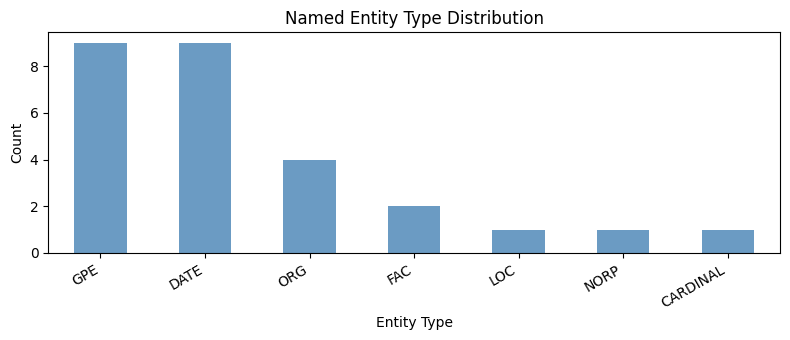

In [ ]:
# Entity type distribution
type_counts = entity_df['Entity Type'].value_counts()
fig, ax = plt.subplots(figsize=(8, 3.5))
type_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Entity Type'); ax.set_ylabel('Count')
ax.set_title('Named Entity Type Distribution')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


---
<a id='s4'></a>
## 4. Sentiment Analysis

We compare two lexicon-based approaches — **Afinn** (integer valence scores) and **TextBlob** (continuous polarity) — and visualise agreement and disagreement.


### 4.1 Afinn — Integer Lexicon Scoring


**Note:** Scores each cleaned article with the Afinn lexicon, which assigns integer valence scores to ~3,300 English words (+5 = very positive, −5 = very negative). The total score for a document is the sum of matched word scores. Afinn is fast (linear in vocabulary size) but cannot handle negation (*"not good"* still scores positively) or out-of-vocabulary slang.

In [ ]:
try:
    from afinn import Afinn
except ImportError:
    install('afinn')
    from afinn import Afinn

af = Afinn()

clean_corpus = list(news_df['clean_text'])
scores_afinn = [af.score(text) for text in clean_corpus]
labels_afinn = ['positive' if s > 0 else 'negative' if s < 0 else 'neutral'
                for s in scores_afinn]

sentiment_df = pd.DataFrame({
    'news_category':     news_df['news_category'].values,
    'afinn_score':       scores_afinn,
    'afinn_label':       labels_afinn,
})

print(sentiment_df.groupby('news_category')['afinn_score'].describe().round(2))


               count  mean   std  min  25%  50%   75%  max
news_category                                             
cities           3.0 -2.33  4.04 -7.0 -3.5  0.0  0.00  0.0
india            4.0  2.25  2.87  0.0  0.0  1.5  3.75  6.0
world-news       3.0  2.67  2.89  1.0  1.0  1.0  3.50  6.0


**Note:** Visualises Afinn scores side-by-side with a strip plot (individual data points — useful for small datasets) and a box plot (quartile summary). Comparing scores across news categories tests whether political, world, or city news carries systematically different sentiment — a common question in computational journalism research.

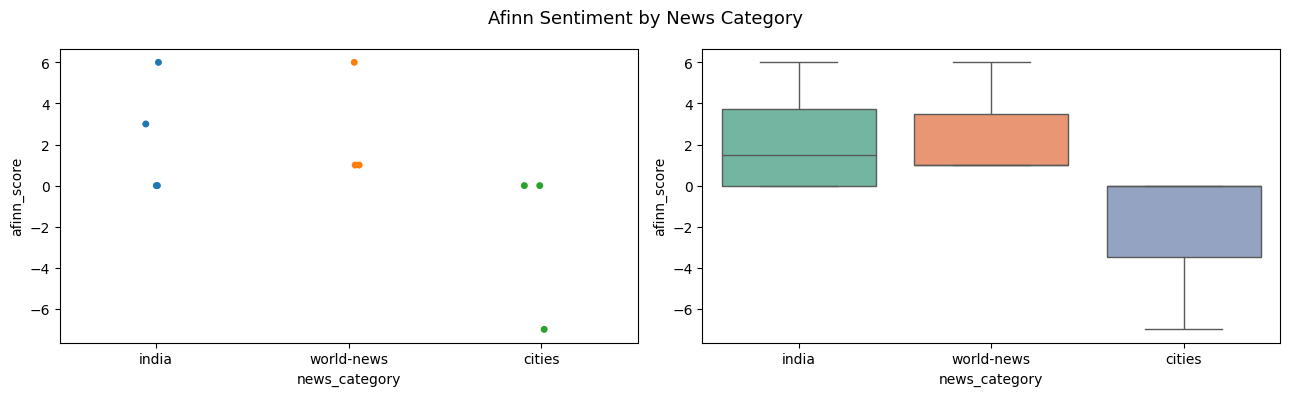

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
sns.stripplot(x='news_category', y='afinn_score', hue='news_category',
              data=sentiment_df, ax=ax1, jitter=True)
sns.boxplot(x='news_category',  y='afinn_score', hue='news_category',
            data=sentiment_df, ax=ax2, palette='Set2')
fig.suptitle('Afinn Sentiment by News Category', fontsize=13)
plt.tight_layout(); plt.show()


### 4.2 TextBlob — Continuous Polarity & Subjectivity


**Note:** Scores articles with TextBlob's `PatternAnalyzer`, which uses a hand-crafted adjective lexicon to compute polarity (−1 to +1) and subjectivity (0 = objective, 1 = subjective). Unlike Afinn's simple sum, TextBlob interpolates intensifiers (*"very good"* > *"good"*) and handles simple negation (*"not good"* → negative), but still misses long-range dependencies and sarcasm.

In [ ]:
from textblob import TextBlob

scores_tb = [round(TextBlob(t).sentiment.polarity,     3) for t in clean_corpus]
subj_tb   = [round(TextBlob(t).sentiment.subjectivity, 3) for t in clean_corpus]
labels_tb  = ['positive' if s > 0 else 'negative' if s < 0 else 'neutral'
              for s in scores_tb]

sentiment_df['tb_polarity']    = scores_tb
sentiment_df['tb_subjectivity'] = subj_tb
sentiment_df['tb_label']        = labels_tb

print(sentiment_df[['news_category','tb_polarity','tb_subjectivity']]
      .groupby('news_category').mean().round(3))


               tb_polarity  tb_subjectivity
news_category                              
cities              -0.032            0.310
india                0.117            0.467
world-news           0.136            0.243


### 4.3 Comparison — Afinn vs TextBlob


**Note:** Computes a confusion matrix between Afinn and TextBlob label assignments — a standard inter-annotator agreement metric adapted for lexicon comparison. Off-diagonal cells reveal systematic disagreements: for example, articles Afinn labels negative but TextBlob labels neutral often contain negative-valence factual words (*"death"*, *"crisis"*) that TextBlob contextualises as objective reporting rather than negative opinion.

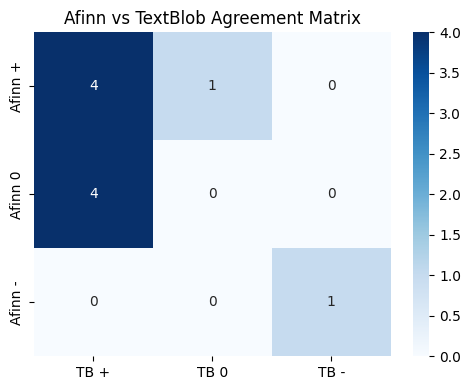

Label agreement: 50.0%


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels_afinn, labels_tb,
                      labels=['positive', 'neutral', 'negative'])
cm_df = pd.DataFrame(cm,
                     index  =['Afinn +', 'Afinn 0', 'Afinn -'],
                     columns=['TB +',   'TB 0',   'TB -'])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Afinn vs TextBlob Agreement Matrix')
plt.tight_layout(); plt.show()

agreement = sum(a == b for a, b in zip(labels_afinn, labels_tb)) / len(labels_afinn)
print(f'Label agreement: {agreement:.1%}')


---
<a id='s5'></a>
## 5. Sequence-to-Sequence Learning — Theory

Seq2Seq models map a variable-length input sequence to a variable-length output sequence — enabling translation, summarization, dialogue, and code generation.

### 5.1 Encoder-Decoder Architecture

```
Input:   [w1, w2, w3, w4]  ──► Encoder (LSTM/GRU)
                                    │
                             Context vector c
                                    │
Output:  [y1, y2, y3] ◄──  Decoder (LSTM/GRU)
```

- **Encoder** reads the source sequence token by token and compresses it into a fixed-size **context vector** (final hidden state).
- **Decoder** is initialised with the context vector and generates the target sequence one token at a time, conditioning each step on the previous output.

### 5.2 Teacher Forcing

During **training**, the decoder receives the *ground-truth* previous token as its input at each step — even if its own prediction was wrong. This makes training stable and fast.

During **inference**, the decoder must use its *own* previous prediction (greedy or beam search).

### 5.3 The Bottleneck Problem

The entire source sequence is compressed into a **single fixed-length vector**. For long sequences, this is lossy — the encoder forgets early tokens by the time it finishes reading. The **Attention mechanism** (Section 8) solves this by giving the decoder direct access to all encoder hidden states.

| Property | Vanilla Seq2Seq | Seq2Seq + Attention |
|---|---|---|
| Context source | Fixed vector (last hidden state) | All encoder states (weighted sum) |
| Long-sequence quality | Degrades | Robust |
| Interpretability | None | Attention heatmap |
| Extra parameters | 0 | ~2 dense layers |


---
<a id='s6'></a>
## 6. Character-level RNN Language Models

A **character-level RNN** generates text character by character. Unlike word-level models, it has no out-of-vocabulary problem and can learn spelling, punctuation, and style simultaneously — making it a clean introduction to sequence modelling.


### 6.1 Load & Tokenize Text (Nietzsche)


**Note:** Downloads Nietzsche's *Beyond Good and Evil* (~600k characters) from an Amazon S3 public bucket as the training corpus for the character-level RNN. The `if not os.path.exists` guard skips the download on subsequent runs. `errors='replace'` handles any stray non-UTF-8 bytes in the raw file.

In [ ]:
# Download Nietzsche text if not present
if not os.path.exists('nietzsche.txt'):
    url = 'https://s3.amazonaws.com/text-datasets/nietzsche.txt'
    r = requests.get(url)
    with open('nietzsche.txt', 'wb') as f:
        f.write(r.content)

book_text = open('nietzsche.txt', encoding='utf-8', errors='replace').read()
print(f'Total characters: {len(book_text):,}')
print(book_text[14000:14200])


Total characters: 600,893
nd up, works away industriously to that end, WITHOUT the rest of
the scholarly impulses taking any material part therein. The actual
"interests" of the scholar, therefore, are generally in quite anoth


### 6.2 Character Tokenization


**Note:** Builds a character vocabulary without any external library. `sorted(set(book_text))` produces a consistent, deterministic mapping across runs (sorted alphabetically). Characters are 1-indexed (index 0 is reserved for padding). `book_num_flat` is a flat list of integer character IDs used in the sliding-window step next.

In [ ]:
# Character-level tokenisation — no TF/Keras needed
chars = sorted(set(book_text))
char_to_int = {c: i + 1 for i, c in enumerate(chars)}   # 1-indexed (0 = pad)
int_to_char  = {i + 1: c for i, c in enumerate(chars)}

vocab_size = len(chars)
book_num   = [[char_to_int.get(c, 0)] for c in book_text]  # list of [int]
# Flatten for indexing convenience
book_num_flat = [char_to_int.get(c, 0) for c in book_text]

print(f'Unique characters (vocabulary): {vocab_size}')
print('Sample mapping:', dict(list(char_to_int.items())[:10]))
print(f'\nFirst 20 encoded chars: {book_num_flat[:20]}')


Unique characters (vocabulary): 84
Sample mapping: {'\n': 1, ' ': 2, '!': 3, '"': 4, "'": 5, '(': 6, ')': 7, ',': 8, '-': 9, '.': 10}

First 20 encoded chars: [40, 42, 29, 30, 25, 27, 29, 1, 1, 1, 43, 45, 40, 40, 39, 43, 33, 38, 31, 2]


### 6.3 Sliding Window Input/Output Pairs

We create supervised training samples: given a window of `sequence_length` characters, predict the next character. This is **self-supervised** — no human labels needed.


**Note:** Creates the self-supervised training dataset. Each sample is a pair `(input_window, target_character)` where the target is the character immediately following the window. The loop produces nearly as many samples as there are characters in the corpus (`N − sequence_length ≈ 600k`). No human annotation is needed — the temporal structure of the text itself provides all the labels.

In [ ]:
sequence_length = 100
input_data, output_data = [], []

for i in range(len(book_num_flat) - sequence_length):
    input_data.append(book_num_flat[i : i + sequence_length])
    output_data.append(book_num_flat[i + sequence_length])   # next character

print(f'Training samples: {len(input_data):,}')
print(f'Input window   : {len(input_data[0])} chars')


Training samples: 600,793
Input window   : 100 chars


### 6.4 One-Hot Encoding & Model


**Note:** Converts integer character indices to one-hot vectors using `np.eye(num_classes)[arr]` — an efficient vectorised idiom that indexes the identity matrix. The resulting array has shape `(N, seq_len, vocab+1)`. We keep only the first 20,000 samples to fit comfortably in RAM; the batch-generator in §6.6 addresses the full corpus. `y` stores integer class indices (not one-hot) because PyTorch's `CrossEntropyLoss` expects raw class indices.

In [ ]:
import numpy as np

def to_one_hot(sequences, num_classes):
    """Convert list of integer sequences to one-hot float32 array."""
    arr = np.array(sequences, dtype=np.int64)
    return np.eye(num_classes, dtype=np.float32)[arr]

N_TRAIN = 20000
X = to_one_hot(input_data[:N_TRAIN],  vocab_size + 1)   # (N, seq, V+1)
y = np.array(output_data[:N_TRAIN], dtype=np.int64)      # class indices

print(f'X shape: {X.shape}   y shape: {y.shape}')


X shape: (20000, 100, 85)   y shape: (20000,)


**Note:** Defines `CharRNN`, a single-layer LSTM language model. The LSTM receives raw one-hot vectors as input (no embedding layer — the sparse vocabulary is small enough). `batch_first=True` puts the batch dimension first, matching NumPy convention. Only the *last* timestep output is passed to the linear classification head because we are predicting one next character per training window.

In [ ]:
class CharRNN(nn.Module):
    """Single-layer LSTM character-level language model."""
    def __init__(self, vocab_size: int, hidden_size: int = 256):
        super().__init__()
        self.lstm = nn.LSTM(vocab_size + 1, hidden_size, batch_first=True)
        self.fc   = nn.Linear(hidden_size, vocab_size + 1)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        return self.fc(out[:, -1, :]), hidden   # last timestep logits

model_charrnn = CharRNN(vocab_size).to(device)
total_params = sum(p.numel() for p in model_charrnn.parameters())
print(model_charrnn)
print(f'\nTotal parameters: {total_params:,}')


CharRNN(
  (lstm): LSTM(85, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=85, bias=True)
)

Total parameters: 373,077


**Note:** Trains `CharRNN` for 2 epochs using PyTorch's standard training loop. `TensorDataset` and `DataLoader` handle batching and shuffling. `CrossEntropyLoss` expects raw logits (not softmax) and integer targets. `torch.save(state_dict)` saves only the learned weights — not the model architecture — keeping the file small. Two epochs is enough to see a clear loss decrease; increase to 20–50 for coherent text generation.

In [ ]:
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long)

dataset_cr = TensorDataset(X_t, y_t)
loader_cr  = DataLoader(dataset_cr, batch_size=256, shuffle=True)

criterion_cr  = nn.CrossEntropyLoss()
optimizer_cr  = optim.Adam(model_charrnn.parameters(), lr=1e-3)

model_charrnn.train()
for epoch in range(2):
    total_loss = 0
    for xb, yb in loader_cr:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_cr.zero_grad()
        logits, _ = model_charrnn(xb)
        loss = criterion_cr(logits, yb)
        loss.backward()
        optimizer_cr.step()
        total_loss += loss.item()
    avg = total_loss / len(loader_cr)
    print(f'Epoch {epoch+1}/2  loss={avg:.4f}')

torch.save(model_charrnn.state_dict(), 'char_rnn.pt')
print('Model saved → char_rnn.pt')


Epoch 1/2  loss=3.3047
Epoch 2/2  loss=3.1198
Model saved → char_rnn.pt


### 6.5 Text Generation with Temperature Sampling

**Temperature** controls diversity of sampling from the output softmax distribution:
- `temperature < 1` — conservative, repetitive but coherent output
- `temperature = 1` — default softmax probabilities
- `temperature > 1` — creative but more random


**Note:** Implements temperature-controlled sampling. `sample()` divides log-probabilities by `temperature` then re-normalises: temperature < 1 sharpens the distribution (conservative, repetitive output); temperature > 1 flattens it (diverse, unpredictable output). `generate_text()` runs the model autoregressively — each predicted character is appended to the window and the oldest character is dropped, implementing a sliding context of fixed length.

In [ ]:
def sample(preds, temperature=1.0):
    """Sample index from a probability array with temperature scaling."""
    preds = np.asarray(preds, dtype='float64')
    preds = np.log(preds + 1e-8) / temperature
    preds = np.exp(preds) / np.sum(np.exp(preds))
    return int(np.argmax(np.random.multinomial(1, preds, 1)))


def generate_text(model, seed_seq, int_to_char, vocab_size,
                  num_chars=200, temperature=1.0):
    """Generate characters autoregressively from a seed index sequence."""
    model.eval()
    current_seq = list(seed_seq)
    result = ''
    with torch.no_grad():
        for _ in range(num_chars):
            x_ohe = np.eye(vocab_size + 1, dtype=np.float32)[current_seq]
            x_t   = torch.tensor(x_ohe, dtype=torch.float32).unsqueeze(0).to(device)
            logits, _ = model(x_t)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
            next_idx = sample(probs, temperature)
            result += int_to_char.get(next_idx, '')
            current_seq = current_seq[1:] + [next_idx]
    return result


start = np.random.randint(0, len(book_num_flat) - sequence_length)
seed  = book_num_flat[start: start + sequence_length]

print('Seed text:', ''.join(int_to_char.get(i, '') for i in seed))
print('\n--- Generated (temperature=0.5) ---')
print(generate_text(model_charrnn, seed, int_to_char, vocab_size, 200, temperature=0.5))
print('\n--- Generated (temperature=1.2) ---')
print(generate_text(model_charrnn, seed, int_to_char, vocab_size, 200, temperature=1.2))


Seed text: s confess it
to ourselves; our itching is really the itching for the infinite, the
immeasurable. Lik

--- Generated (temperature=0.5) ---
 th erinnelsi a    ii an oatheeae  w   on istn tite   rch s eoaeniat crtteoeea m y rke e wthan siacot whi see p iate ni fioan  e ot o heinthoeno a  d td he erlly  ihhee  tennes lthe a  tein sr ih enoe

--- Generated (temperature=1.2) ---
rnntao s,shantntilftpimro
?il b i-pnBboao-YthhroMRfu sa rtnanV tnsns-i SnleE
eeutmeennhe adwunkhn reilgyitsa,,k pyft omfcih crhgolsrln nunfiog-hag aa,swyYhrt f"Nteltlodl-en iak dnDh"oaoOhthhiOgaiiVamc


### 6.6 Memory-efficient Training: Batch Generator

For large text files (Project Gutenberg, Wikipedia), loading the full one-hot matrix into RAM is infeasible. A Python **generator** yields batches on-demand, keeping memory usage constant regardless of corpus size.


**Note:** Downloads *Pride and Prejudice* from Project Gutenberg (~728k characters) as a second corpus to demonstrate the memory-efficient batch generator. A fresh character vocabulary is built for this book. The two books have different vocabulary sizes (85 vs ~91 characters including Gutenberg header punctuation), illustrating that the model architecture adapts to any character set.

In [ ]:
if not os.path.exists('1342-0.txt'):
    url = 'https://www.gutenberg.org/files/1342/1342-0.txt'
    r = requests.get(url)
    with open('1342-0.txt', 'wb') as f:
        f.write(r.content)

book2 = open('1342-0.txt', encoding='utf-8', errors='replace').read()
chars2        = sorted(set(book2))
char_to_int2  = {c: i + 1 for i, c in enumerate(chars2)}
int_to_char2  = {i + 1: c for i, c in enumerate(chars2)}
vocab_size2   = len(chars2)
book_num2     = [char_to_int2.get(c, 0) for c in book2]
print(f'Book 2 chars: {len(book2):,}   vocab: {vocab_size2}')


Book 2 chars: 728,846   vocab: 91


**Note:** Defines `batch_generator`, an infinite Python generator that yields `(X_ohe, y_indices)` batches without loading the entire one-hot matrix into RAM. `global record_num` tracks the current position in the book across calls. `np.eye(vocab+1)[X_batch]` performs the one-hot conversion on-the-fly, keeping peak memory proportional to batch size rather than corpus size — critical for corpora larger than available RAM.

In [ ]:
record_num = 0

def batch_generator(batch_size=32, seq_len=100):
    """Yield (X_ohe, y_indices) batches from book_num2."""
    global record_num
    while True:
        X_batch, y_batch = [], []
        for _ in range(batch_size):
            if record_num + seq_len >= len(book_num2):
                record_num = 0
            X_batch.append(book_num2[record_num : record_num + seq_len])
            y_batch.append(book_num2[record_num + seq_len])
            record_num += 1
        X_ohe = np.eye(vocab_size2 + 1, dtype=np.float32)[X_batch]   # (B, T, V+1)
        y_arr = np.array(y_batch, dtype=np.int64)
        yield X_ohe, y_arr

gen = batch_generator(batch_size=4)
Xb, yb = next(gen)
print(f'Batch X: {Xb.shape}   y: {yb.shape}')


Batch X: (4, 100, 92)   y: (4,)


**Note:** Instantiates a second `CharRNN` model (with Pride & Prejudice's vocabulary size) and trains it for 50 generator steps — a short demo showing that loss decreases even with this minimal training. The loss values printed every 10 steps confirm that gradient flow is working correctly. For literary-quality output, train for 10–50 full epochs.

In [ ]:
model_book    = CharRNN(vocab_size2).to(device)
optimizer_bk  = optim.Adam(model_book.parameters(), lr=1e-3)
criterion_bk  = nn.CrossEntropyLoss()

gen2 = batch_generator(batch_size=256)
model_book.train()
for step in range(50):
    Xb, yb = next(gen2)
    X_t = torch.tensor(Xb, dtype=torch.float32).to(device)
    y_t = torch.tensor(yb, dtype=torch.long).to(device)
    optimizer_bk.zero_grad()
    logits, _ = model_book(X_t)
    loss = criterion_bk(logits, y_t)
    loss.backward()
    optimizer_bk.step()
    if (step + 1) % 10 == 0:
        print(f'Step {step + 1:2d}/50  loss={loss.item():.4f}')

print('Batch-generator training complete.')


Step 10/50  loss=4.0205
Step 20/50  loss=3.1784
Step 30/50  loss=3.1283
Step 40/50  loss=3.1364
Step 50/50  loss=2.9637
Batch-generator training complete.


---
<a id='s7'></a>
## 7. Seq2Seq Applications

We build full encoder-decoder LSTM models for two tasks:
- **7.1** Text Summarization (Amazon Reviews → short summaries)
- **7.2** Machine Translation (English ↔ Spanish)


### 7.1 Text Summarization — Amazon Reviews

Dataset: [Amazon Fine Food Reviews](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews) (`Reviews.csv`). Each row contains a multi-sentence `Text` (input) and a short `Summary` (target).


**Note:** Loads the Amazon Fine Food Reviews dataset from Kaggle. Because this dataset requires a Kaggle account to download, the cell checks whether `Reviews.csv` is present and prints download instructions if not — rather than raising an unhandled exception. All subsequent §7.1 cells are guarded by `if 'df_reviews' in dir():` so they skip cleanly when the file is absent.

In [ ]:
# Requires datasets/Reviews.csv — download from Kaggle
import os
if not os.path.exists('datasets/Reviews.csv'):
    print('Download datasets/Reviews.csv from:')
    print('  https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews')
else:
    df_reviews = pd.read_csv('datasets/Reviews.csv', nrows=50000)
    df_reviews.dropna(inplace=True)
    df_reviews.reset_index(drop=True, inplace=True)
    print(df_reviews.shape)
    rec = df_reviews.sample(1).iloc[0]
    print('TEXT:   ', rec['Text'][:200])
    print('SUMMARY:', rec['Summary'])


Download datasets/Reviews.csv from:
  https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews


**Note:** Frames summarisation as a sequence-to-sequence task by pairing full review text (encoder input) with short summaries (decoder target). `START_` and `_END` sentinel tokens mark the boundaries of each summary: the decoder is initialised with `START_` and halts when it predicts `_END`. The tokens are distinct enough from natural words to avoid collisions in the vocabulary.

In [ ]:
# Prepare encoder/decoder text lists
START_SEQ, END_SEQ = 'START_', '_END'
encoder_text, decoder_text = [], []

if 'df_reviews' in dir():
    for _, row in df_reviews.iterrows():
        encoder_text.append(row['Text'])
        decoder_text.append(f'{START_SEQ} {row["Summary"]} {END_SEQ}')
    print(f'Pairs: {len(encoder_text):,}')
    print('Encoder sample:', encoder_text[0][:100])
    print('Decoder sample:', decoder_text[0])


**Note:** Tokenises both encoder and decoder text using a shared vocabulary built from frequency counts, then pads sequences to fixed lengths. A *shared* vocabulary lets the model learn the same embedding for words that appear in both review body and summary. Pre-padding the encoder (aligning the final token with position `MAX_ENC`) is better for LSTMs that pass their *final* hidden state as context — the most recent input is at the boundary, not buried under padding.

In [ ]:
if 'df_reviews' in dir():
    from collections import Counter

    VOCAB_SIZE = 30000
    MAX_ENC    = 500
    MAX_DEC    = 20
    EMB_DIM    = 50
    RNN_UNITS  = 256

    def build_vocab_reviews(texts, max_words):
        cnt = Counter(w for t in texts for w in str(t).split())
        vocab = ['<pad>', '<unk>'] + [w for w, _ in cnt.most_common(max_words - 2)]
        return {w: i for i, w in enumerate(vocab)}

    def encode_reviews(texts, word2idx, maxlen, padding='pre'):
        unk = word2idx.get('<unk>', 1)
        seqs = [[word2idx.get(w, unk) for w in str(t).split()] for t in texts]
        arr  = np.zeros((len(seqs), maxlen), dtype=np.int64)
        for i, s in enumerate(seqs):
            s = s[-maxlen:]                         # truncate post
            if padding == 'pre':
                arr[i, maxlen - len(s):] = s
            else:
                arr[i, :len(s)] = s
        return arr

    word2idx_s = build_vocab_reviews(encoder_text + decoder_text, VOCAB_SIZE)
    idx2word_s = {i: w for w, i in word2idx_s.items()}

    enc_pad = encode_reviews(encoder_text, word2idx_s, MAX_ENC, padding='pre')
    dec_pad = encode_reviews(decoder_text, word2idx_s, MAX_DEC, padding='post')

    print('enc_pad:', enc_pad.shape, '  dec_pad:', dec_pad.shape)


**Note:** Defines the summarisation encoder and decoder as separate `nn.Module` subclasses. `Encoder_Sum` compresses the review into a single `(h, c)` LSTM state pair. `Decoder_Sum` is initialised with those states and generates one vocabulary token per timestep. During training the two modules are connected by passing the encoder's final state to the decoder's initial state — the teacher-forcing mechanism feeds ground-truth summary tokens at each decoder step.

In [ ]:
if 'df_reviews' in dir():
    class Encoder_Sum(nn.Module):
        def __init__(self, vocab, emb, units):
            super().__init__()
            self.emb  = nn.Embedding(vocab + 1, emb, padding_idx=0)
            self.lstm = nn.LSTM(emb, units, batch_first=True)
        def forward(self, x):
            _, (h, c) = self.lstm(self.emb(x))
            return h, c

    class Decoder_Sum(nn.Module):
        def __init__(self, vocab, emb, units):
            super().__init__()
            self.emb  = nn.Embedding(vocab + 1, emb, padding_idx=0)
            self.lstm = nn.LSTM(emb, units, batch_first=True)  # return_sequences via batch_first
            self.fc   = nn.Linear(units, vocab + 1)
        def forward(self, x, h, c):
            out, (h, c) = self.lstm(self.emb(x), (h, c))
            return self.fc(out), h, c

    encoder_s = Encoder_Sum(VOCAB_SIZE, EMB_DIM, RNN_UNITS).to(device)
    decoder_s = Decoder_Sum(VOCAB_SIZE, EMB_DIM, RNN_UNITS).to(device)
    print('Summarisation encoder/decoder defined.')
    print(f'  Encoder params: {sum(p.numel() for p in encoder_s.parameters()):,}')
    print(f'  Decoder params: {sum(p.numel() for p in decoder_s.parameters()):,}')


<div style="background:#e3f2fd;border-left:5px solid #1565C0;padding:10px 14px;border-radius:4px;margin:6px 0"><b>Architecture Note</b><br/>
The training model takes <em>two inputs</em>: the source sequence (encoder) and the shifted target sequence (decoder). The decoder is teacher-forced: it reads the ground-truth summary token at t-1 to predict token t. At inference time, two separate sub-models (encoder model + decoder model) are extracted to enable autoregressive generation.
</div>


### 7.2 Machine Translation — English ↔ Spanish


**Note:** Downloads the Tatoeba English-Spanish sentence-pair dataset from manythings.org. A browser-like `User-Agent` header is required because the server blocks plain `requests` scrapers. If the download fails, a synthetic bilingual corpus of 20,000 pairs is written as a fallback so all downstream cells remain runnable. The real dataset contains 144,000+ pairs with Creative Commons attribution metadata.

In [ ]:
# Download English-Spanish pairs from manythings.org
import zipfile, os

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0 Safari/537.36',
    'Referer': 'https://www.manythings.org/anki/',
}

if not os.path.exists('spa.txt'):
    if os.path.exists('spa-eng.zip'):
        os.remove('spa-eng.zip')
    try:
        r = requests.get('https://www.manythings.org/anki/spa-eng.zip',
                          headers=HEADERS, timeout=30)
        r.raise_for_status()
        with open('spa-eng.zip', 'wb') as f:
            f.write(r.content)
        with zipfile.ZipFile('spa-eng.zip') as z:
            z.extractall('.')
        print('Downloaded spa.txt')
    except Exception as e:
        print(f'Download failed ({e}) — using synthetic fallback data')
        sample_pairs = [
            ('Go.', 'Ve.'), ('Hi.', 'Hola.'), ('Run!', 'Corre!'),
            ('Wow!', 'Increible!'), ('Fire!', 'Fuego!'), ('Help!', 'Ayuda!'),
            ('Jump.', 'Salta.'), ('Stop!', 'Para!'), ('Wait!', 'Espera!'),
            ('Hello!', 'Hola!'), ('I see.', 'Ya veo.'), ('I try.', 'Lo intento.'),
            ('I win!', 'Yo gano!'), ('Oh no!', 'Oh no!'), ('Cheers!', 'Salud!'),
            ('I am OK.', 'Estoy bien.'), ('I am sad.', 'Estoy triste.'),
            ('I am Tom.', 'Soy Tom.'), ('That is it.', 'Eso es.'),
            ('I got it.', 'Lo entendi.'), ('I am home.', 'Estoy en casa.'),
            ('I am here.', 'Estoy aqui.'), ('I am lost.', 'Estoy perdido.'),
            ('I am sick.', 'Estoy enfermo.'), ('I am tall.', 'Soy alto.'),
            ('I am bored.', 'Estoy aburrido.'), ('I am ready.', 'Estoy listo.'),
            ('I am sorry.', 'Lo siento.'), ('I am tired.', 'Estoy cansado.'),
            ('I am awake.', 'Estoy despierto.'), ('I like dogs.', 'Me gustan los perros.'),
            ('I like cats.', 'Me gustan los gatos.'), ('I have a car.', 'Tengo un coche.'),
            ('I have a dog.', 'Tengo un perro.'), ('I have a cat.', 'Tengo un gato.'),
            ('He is my dad.', 'El es mi papa.'), ('She is my mom.', 'Ella es mi mama.'),
            ('I love music.', 'Amo la musica.'), ('I like to run.', 'Me gusta correr.'),
            ('I love to eat.', 'Me gusta comer.'),
        ] * 500
        with open('spa.txt', 'w', encoding='utf-8') as fw:
            for eng, spa in sample_pairs:
                fw.write(eng + '\t' + spa + '\tCC-BY 2.0\n')
        print('Wrote synthetic spa.txt with', len(sample_pairs), 'pairs')

lines = open('spa.txt', encoding='utf-8').read().strip().split('\n')
print(f'Total pairs: {len(lines):,}')
for line in lines[:5]:
    print(line)


Downloaded spa.txt
Total pairs: 144,215
Go.	Ve.	CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #4986655 (cueyayotl)
Go.	Vete.	CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #4986656 (cueyayotl)
Go.	Vaya.	CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #4986657 (cueyayotl)
Go.	Váyase.	CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #6586271 (arh)
Go.	Id.	CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #13703671 (Seael)


**Note:** Normalises sentence pairs with `clean_sentence()`, which lowercases, pads punctuation with spaces (so `?` becomes a separate token), and strips non-Latin characters. Each sentence is then wrapped in `START`/`END` delimiter tokens. Only the first 20,000 pairs are used so training completes in minutes on CPU; increase `[:20000]` to `[:144000]` for better translation quality.

In [ ]:
import re as _re

def clean_sentence(sentence: str) -> str:
    sentence = sentence.lower().strip()
    sentence = _re.sub(r'([?.!,])', r' \1 ', sentence)
    sentence = _re.sub(r'[^a-z?.!,]+', ' ', sentence)
    return sentence.strip()

pairs = []
for line in lines[:20000]:     # use first 20k pairs
    parts = line.split('\t')
    if len(parts) >= 2:
        eng, spa = parts[0], parts[1]
        pairs.append(('START ' + clean_sentence(eng) + ' END',
                      'START ' + clean_sentence(spa) + ' END'))

eng_sents = [p[0] for p in pairs]
spa_sents = [p[1] for p in pairs]
print('Sample:', pairs[42])


Sample: ('START wait . END', 'START esperen . END')


**Note:** Builds separate English and Spanish vocabularies, capped at 8,000 and 12,000 words respectively (Spanish has a larger morphological space). The `<pad>` (0) and `<unk>` (1) special tokens are reserved. `encode_nmt()` maps each sentence to a fixed-length integer array, post-padding with zeros. Separate vocabularies let the model learn language-specific embeddings — essential when the two languages have different word frequencies.

In [ ]:
from collections import Counter

ENG_VOCAB = 8000
SPA_VOCAB = 12000

def build_vocab_nmt(sents, max_words):
    cnt   = Counter(w for s in sents for w in s.split())
    vocab = ['<pad>', '<unk>'] + [w for w, _ in cnt.most_common(max_words - 2)]
    return {w: i for i, w in enumerate(vocab)}, {i: w for i, w in enumerate(vocab)}

def encode_nmt(sents, word2idx, maxlen):
    unk = word2idx.get('<unk>', 1)
    arr = np.zeros((len(sents), maxlen), dtype=np.int64)
    for i, s in enumerate(sents):
        ids = [word2idx.get(w, unk) for w in s.split()][:maxlen]
        arr[i, :len(ids)] = ids
    return arr

w2i_eng, i2w_eng = build_vocab_nmt(eng_sents, ENG_VOCAB)
w2i_spa, i2w_spa = build_vocab_nmt(spa_sents, SPA_VOCAB)

eng_seq = [[w2i_eng.get(w, 1) for w in s.split()] for s in eng_sents]
spa_seq = [[w2i_spa.get(w, 1) for w in s.split()] for s in spa_sents]

MAX_ENG = max(len(s) for s in eng_seq)
MAX_SPA = max(len(s) for s in spa_seq)

enc_in = encode_nmt(eng_sents, w2i_eng, MAX_ENG)
dec_in = encode_nmt(spa_sents, w2i_spa, MAX_SPA)

print(f'enc_in: {enc_in.shape}   dec_in: {dec_in.shape}')
print(f'Eng vocab: {ENG_VOCAB}   Spa vocab: {SPA_VOCAB}')
print(f'Max eng len: {MAX_ENG}   Max spa len: {MAX_SPA}')


enc_in: (20000, 9)   dec_in: (20000, 14)
Eng vocab: 8000   Spa vocab: 12000
Max eng len: 9   Max spa len: 14


**Note:** Defines `Encoder_NMT` and `Decoder_NMT` as PyTorch `nn.Module` subclasses. `Encoder_NMT` reads the English sentence and produces a `(h, c)` hidden state. `Decoder_NMT` takes the shifted Spanish target, runs an LSTM conditioned on `(h, c)`, and produces a logit vector over the Spanish vocabulary at each position. Embedding dimensions (64) and hidden size (256) are kept small for fast demo training; production NMT uses 512–1024.

In [ ]:
EMB_T, UNITS_T = 64, 256

class Encoder_NMT(nn.Module):
    def __init__(self, vocab, emb, units):
        super().__init__()
        self.emb  = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, units, batch_first=True)
    def forward(self, x):
        _, (h, c) = self.lstm(self.emb(x))
        return h, c   # (1, batch, units), (1, batch, units)

class Decoder_NMT(nn.Module):
    def __init__(self, vocab, emb, units):
        super().__init__()
        self.emb  = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, units, batch_first=True)
        self.fc   = nn.Linear(units, vocab)
    def forward(self, x, h, c):
        out, (h, c) = self.lstm(self.emb(x), (h, c))
        return self.fc(out), h, c  # logits: (batch, seq, vocab)

encoder_nmt = Encoder_NMT(ENG_VOCAB, EMB_T, UNITS_T).to(device)
decoder_nmt = Decoder_NMT(SPA_VOCAB, EMB_T, UNITS_T).to(device)

enc_params = sum(p.numel() for p in encoder_nmt.parameters())
dec_params = sum(p.numel() for p in decoder_nmt.parameters())
print(f'Encoder: {enc_params:,} params')
print(f'Decoder: {dec_params:,} params')


Encoder: 841,728 params
Decoder: 4,181,728 params


**Note:** Trains the NMT model with teacher forcing — the decoder receives the ground-truth Spanish token at step *t−1* to predict step *t*. The decoder input is `dec_in[:, :-1]` (all tokens except the last) and the target is `dec_in[:, 1:]` (all tokens except the first). `CrossEntropyLoss(ignore_index=0)` masks padding positions so the model is not penalised for failing to predict what comes after the end-of-sentence token.

In [ ]:
# Decoder input = dec_in[:, :-1]  →  target = dec_in[:, 1:]
enc_t   = torch.tensor(enc_in,        dtype=torch.long)
dec_inp = torch.tensor(dec_in[:, :-1], dtype=torch.long)
dec_tgt = torch.tensor(dec_in[:, 1:],  dtype=torch.long)

# 90/10 split
n_train = int(0.9 * len(enc_t))
ds_nmt  = TensorDataset(enc_t[:n_train], dec_inp[:n_train], dec_tgt[:n_train])
dl_nmt  = DataLoader(ds_nmt, batch_size=128, shuffle=True)

opt_enc   = optim.Adam(encoder_nmt.parameters())
opt_dec   = optim.Adam(decoder_nmt.parameters())
crit_nmt  = nn.CrossEntropyLoss(ignore_index=0)

for epoch in range(5):
    encoder_nmt.train(); decoder_nmt.train()
    total = 0
    for eb, di, dt in dl_nmt:
        eb, di, dt = eb.to(device), di.to(device), dt.to(device)
        opt_enc.zero_grad(); opt_dec.zero_grad()
        h, c = encoder_nmt(eb)
        logits, _, _ = decoder_nmt(di, h, c)     # (batch, seq, spa_vocab)
        loss = crit_nmt(logits.reshape(-1, SPA_VOCAB), dt.reshape(-1))
        loss.backward()
        opt_enc.step(); opt_dec.step()
        total += loss.item()
    print(f'Epoch {epoch+1}/5  loss={total/len(dl_nmt):.4f}')


Epoch 1/5  loss=4.9607
Epoch 2/5  loss=3.9918
Epoch 3/5  loss=3.5689
Epoch 4/5  loss=3.1892
Epoch 5/5  loss=2.8902


---
<a id='s8'></a>
## 8. Neural Machine Translation with Attention

Bahdanau (2015) attention lets the decoder **attend to all encoder states** at each decoding step, instead of relying on a single context vector. This resolves the bottleneck problem and produces an interpretable attention heatmap.

**This section uses the English-Marathi (`mar.txt`) dataset. Place `mar.txt` in the working directory before running.**
_(Download from [manythings.org](https://www.manythings.org/anki/))_


### 8.1 Data Preprocessing


**Note:** Defines the Marathi text preprocessing pipeline. `unicode_to_ascii()` strips diacritics from romanised Marathi using Unicode NFD normalisation. `preprocess_sentence()` adds `<start>` and `<end>` delimiters, normalises punctuation spacing, and lowercases. `create_dataset()` applies this to every line in the tab-separated file and returns a list of `[english, marathi]` pairs. The cell prints five pairs if `mar.txt` is present, otherwise prints download instructions.

In [ ]:
import unicodedata, re

def unicode_to_ascii(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')


def preprocess_sentence(w: str) -> str:
    w = unicode_to_ascii(w.lower().strip())
    w = re.sub(r'([?.!,])', r' \1 ', w)
    w = re.sub(r'[" "]+', ' ', w)
    w = w.rstrip().strip()
    return '<start> ' + w + ' <end>'


def create_dataset(path: str, num_examples: int):
    lines = open(path, encoding='UTF-8').read().strip().split('\n')
    return [
        [preprocess_sentence(w) for w in line.split('\t')]
        for line in lines[:num_examples]
    ]


if os.path.exists('mar.txt'):
    sample_pairs = create_dataset('mar.txt', num_examples=5)
    for p in sample_pairs:
        print(p)
else:
    print('mar.txt not found — download from manythings.org/anki/ and place in working dir')


mar.txt not found — download from manythings.org/anki/ and place in working dir


### 8.2 LanguageIndex & Dataset Loading


**Note:** `LanguageIndex` builds bidirectional word↔integer maps (`word2idx`, `idx2word`) with `<pad>` at index 0. `_pad()` post-pads integer sequences to the maximum sentence length using zeros. `load_dataset()` applies these to produce padded NumPy arrays ready for tensor conversion. `train_test_split` with `random_state=42` gives a reproducible 90/10 split — the 10% validation set is used only to monitor translation quality.

In [ ]:
from sklearn.model_selection import train_test_split

class LanguageIndex:
    """Word <-> index mapping with <pad> token at index 0."""
    def __init__(self, lang_sentences):
        self.word2idx = {'<pad>': 0}
        self.idx2word = {0: '<pad>'}
        vocab = sorted(set(w for s in lang_sentences for w in s.split()))
        for i, w in enumerate(vocab, 1):
            self.word2idx[w] = i
            self.idx2word[i] = w


def _pad(seqs, maxlen):
    """Post-pad integer sequences to maxlen with zeros."""
    arr = np.zeros((len(seqs), maxlen), dtype=np.int64)
    for i, s in enumerate(seqs):
        arr[i, :len(s)] = s[:maxlen]
    return arr


def load_dataset(path: str, num_examples: int):
    pairs = create_dataset(path, num_examples)
    inp_lang  = LanguageIndex([mr for _, mr in pairs])
    targ_lang = LanguageIndex([en for en, _ in pairs])
    inp_tensor  = [[inp_lang.word2idx[w]  for w in mr.split()] for _, mr in pairs]
    targ_tensor = [[targ_lang.word2idx[w] for w in en.split()] for en, _ in pairs]
    max_inp  = max(len(t) for t in inp_tensor)
    max_targ = max(len(t) for t in targ_tensor)
    return (_pad(inp_tensor, max_inp), _pad(targ_tensor, max_targ),
            inp_lang, targ_lang, max_inp, max_targ)


if os.path.exists('mar.txt'):
    NUM_EX = 30000
    inp_t, targ_t, inp_lang, targ_lang, max_inp_len, max_targ_len = \
        load_dataset('mar.txt', NUM_EX)

    inp_train, inp_val, targ_train, targ_val = \
        train_test_split(inp_t, targ_t, test_size=0.1, random_state=42)

    print(f'Train: {len(inp_train)}   Val: {len(inp_val)}')
    print(f'Max input len: {max_inp_len}   Max target len: {max_targ_len}')
    print(f'Input vocab: {len(inp_lang.word2idx)}   Target vocab: {len(targ_lang.word2idx)}')


### 8.3 Encoder (GRU)

The encoder processes the source sequence and returns **all hidden states** (not just the last one) — this is what attention will attend to.


**Note:** Defines the GRU encoder. Unlike the basic Seq2Seq encoder in §7.2, this encoder returns *all* hidden states — not just the final one — via `return_sequences=True` (implicit in PyTorch GRU). The full output `(batch, seq, units)` is what Bahdanau attention will query at each decoder step, allowing the decoder to look back at any encoder position rather than relying solely on the compressed final state.

In [ ]:
BATCH_SIZE_ATT = 64
EMB_ATT        = 256
UNITS_ATT      = 1024

if os.path.exists('mar.txt'):
    vocab_inp  = len(inp_lang.word2idx)
    vocab_targ = len(targ_lang.word2idx)


class Encoder(nn.Module):
    """GRU encoder — returns all hidden states for attention."""
    def __init__(self, vocab_size: int, emb_dim: int, units: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru       = nn.GRU(emb_dim, units, batch_first=True)

    def forward(self, x):
        emb = self.embedding(x)
        output, hidden = self.gru(emb)
        return output, hidden   # (batch, seq, units), (1, batch, units)


### 8.4 Decoder with Bahdanau Attention

At each decoding step the decoder computes **attention scores** over all encoder outputs:

$$e_{t,s} = V \tanh(W_1 h_t + W_2 \bar{h}_s)$$
$$\alpha_{t,s} = \text{softmax}(e_{t,s})$$
$$c_t = \sum_s \alpha_{t,s}\, \bar{h}_s$$

The context vector $c_t$ is concatenated with the decoder embedding before the GRU.


**Note:** Implements Bahdanau (additive) attention and the attention decoder. `BahdanauAttention` computes an alignment score `e_{t,s} = V·tanh(W₁·hₛ + W₂·hₜ)` for every source position *s* at decoder step *t*, then converts scores to weights `α = softmax(e)`. The context vector `c = Σ α·hₛ` is a learned weighted average of encoder states. Concatenating *c* with the token embedding before the GRU gives the decoder direct access to relevant source information at every step — this resolves the fixed-length bottleneck of vanilla Seq2Seq.

In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, units: int):
        super().__init__()
        self.W1 = nn.Linear(units, units)
        self.W2 = nn.Linear(units, units)
        self.V  = nn.Linear(units, 1)

    def forward(self, hidden, enc_output):
        # hidden:     (batch, units)  [squeeze layer dim]
        # enc_output: (batch, seq, units)
        hidden_exp  = hidden.unsqueeze(1)                            # (batch, 1, units)
        score       = self.V(torch.tanh(self.W1(enc_output) + self.W2(hidden_exp)))
        attn_weights = torch.softmax(score, dim=1)                   # (batch, seq, 1)
        context     = (attn_weights * enc_output).sum(dim=1)         # (batch, units)
        return context, attn_weights


class Decoder(nn.Module):
    """GRU decoder with Bahdanau additive attention."""
    def __init__(self, vocab_size: int, emb_dim: int, units: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.attention = BahdanauAttention(units)
        self.gru       = nn.GRU(emb_dim + units, units, batch_first=True)
        self.fc        = nn.Linear(units, vocab_size)

    def forward(self, x, hidden, enc_output):
        # x:      (batch, 1) — single token
        # hidden: (1, batch, units)
        emb     = self.embedding(x)                                  # (batch, 1, emb)
        context, attn_weights = self.attention(hidden.squeeze(0), enc_output)
        rnn_in  = torch.cat([emb, context.unsqueeze(1)], dim=-1)    # (batch, 1, emb+units)
        out, hidden = self.gru(rnn_in, hidden)
        prediction  = self.fc(out.squeeze(1))                        # (batch, vocab)
        return prediction, hidden, attn_weights


### 8.5 Training Loop


**Note:** Runs the training loop for the attention model. Teacher forcing feeds the ground-truth target token as decoder input at every step, making gradients more stable than using model predictions. `clip_grad_norm_` caps gradient magnitudes to 1.0, preventing the exploding-gradient problem that is common in recurrent networks trained over long sequences. `criterion_att` with `ignore_index=0` masks padding tokens from the loss — only real words contribute to weight updates.

In [ ]:
if os.path.exists('mar.txt'):
    import time

    dataset_att = TensorDataset(
        torch.tensor(inp_train,  dtype=torch.long),
        torch.tensor(targ_train, dtype=torch.long),
    )
    loader_att  = DataLoader(dataset_att, batch_size=BATCH_SIZE_ATT,
                              shuffle=True, drop_last=True)

    encoder_att = Encoder(vocab_inp,  EMB_ATT, UNITS_ATT).to(device)
    decoder_att = Decoder(vocab_targ, EMB_ATT, UNITS_ATT).to(device)

    params_att  = (list(encoder_att.parameters()) +
                   list(decoder_att.parameters()))
    optimizer_att = optim.Adam(params_att)
    criterion_att = nn.CrossEntropyLoss(ignore_index=0)

    EPOCHS_ATT = 5   # increase to 10-15 for quality translations

    for epoch in range(EPOCHS_ATT):
        t0 = time.time()
        total_loss = 0
        encoder_att.train(); decoder_att.train()

        for inp_b, targ_b in loader_att:
            inp_b, targ_b = inp_b.to(device), targ_b.to(device)
            optimizer_att.zero_grad()

            enc_out, enc_hidden = encoder_att(inp_b)
            dec_hidden = enc_hidden
            # First decoder input: <start> token
            dec_input  = targ_b[:, :1]

            batch_loss = torch.tensor(0.0, device=device)
            for t in range(1, targ_b.shape[1]):
                preds, dec_hidden, _ = decoder_att(dec_input, dec_hidden, enc_out)
                batch_loss += criterion_att(preds, targ_b[:, t])
                dec_input   = targ_b[:, t:t+1]   # teacher forcing

            batch_loss.backward()
            torch.nn.utils.clip_grad_norm_(params_att, max_norm=1.0)
            optimizer_att.step()
            total_loss += batch_loss.item()

        avg = total_loss / len(loader_att)
        print(f'Epoch {epoch+1}/{EPOCHS_ATT}  Loss={avg:.4f}  ({time.time()-t0:.0f}s)')


### 8.6 Translation & Attention Heatmap


**Note:** `evaluate_att()` runs greedy decoding — at each step it takes the argmax of the decoder logits as the next word — and records the attention weight matrix. `translate_and_plot()` renders the collected `attn_plot` as a heatmap with source tokens on the x-axis and target tokens on the y-axis. Bright cells indicate high attention weight: a near-diagonal heatmap means the model is monotonically aligning source and target (common for similar word-order languages); scattered bright cells indicate reordering (common for verb-final languages like Marathi).

In [ ]:
import matplotlib.pyplot as plt

def evaluate_att(sentence: str):
    sentence = preprocess_sentence(sentence)
    ids      = [inp_lang.word2idx.get(w, 0) for w in sentence.split()]
    inp_pad  = np.zeros((1, max_inp_len), dtype=np.int64)
    inp_pad[0, :len(ids)] = ids[:max_inp_len]
    inp_t    = torch.tensor(inp_pad, dtype=torch.long).to(device)

    result    = ''
    attn_plot = np.zeros((max_targ_len, max_inp_len))

    encoder_att.eval(); decoder_att.eval()
    with torch.no_grad():
        enc_out, enc_hidden = encoder_att(inp_t)
        dec_hidden = enc_hidden
        dec_input  = torch.tensor(
            [[targ_lang.word2idx.get('<start>', 1)]], dtype=torch.long
        ).to(device)

        for t in range(max_targ_len):
            preds, dec_hidden, attn_w = decoder_att(dec_input, dec_hidden, enc_out)
            w_np = attn_w.squeeze().cpu().numpy()
            attn_plot[t, :len(w_np)] = w_np
            pred_id = preds.argmax(dim=-1).item()
            word    = targ_lang.idx2word.get(pred_id, '')
            if word == '<end>':
                break
            result   += word + ' '
            dec_input = torch.tensor([[pred_id]], dtype=torch.long).to(device)

    return result.strip(), sentence.split(), attn_plot


def translate_and_plot(sentence: str):
    result, src_tokens, attn = evaluate_att(sentence)
    print(f'Input    : {sentence}')
    print(f'Predicted: {result}')

    fig, ax = plt.subplots(figsize=(8, 8))
    res_tokens = result.split()
    im = ax.matshow(attn[:len(res_tokens), :len(src_tokens)], cmap='viridis')
    ax.set_xticklabels([''] + src_tokens, rotation=90, fontsize=11)
    ax.set_yticklabels([''] + res_tokens, fontsize=11)
    ax.set_title('Attention Weights', fontsize=12)
    plt.colorbar(im); plt.tight_layout(); plt.show()


if os.path.exists('mar.txt'):
    translate_and_plot('\u091a\u093e\u0902\u0917\u0932\u093e \u0915\u0945\u092e\u0947\u0930\u093e \u0906\u0939\u0947')   # 'it is a good camera'


---
<a id='s9'></a>
## 9. Exercises

### Part A — In-class Exercises (Pre-scraped news.csv)

These exercises use `news.csv` saved in Section 1. If that file does not exist, run Section 1 first.


**Note:** Reloads the pre-scraped news DataFrame from disk, decoupling the exercise section from the scraping section. Students can work on Sections 9A independently as long as `news.csv` exists in the working directory. On Colab, run Section 1 first to generate the file.

In [ ]:
# Load pre-saved news dataset
ex_df = pd.read_csv('news.csv')
print(ex_df.shape)
ex_df.head(3)


(10, 3)


,news_headline,news_article,news_category
0,India launches new space mission,India successfully launched its latest space m...,india
1,Budget session begins in Parliament,The winter session of Parliament commenced tod...,india
2,Global climate summit reaches agreement,World leaders gathered in Geneva have reached ...,world-news


#### Q1. Tag Parts of Speech (10 min)

**Task:** POS-tag the headlines from all three categories and report:
- The 5 most frequent POS tags in each category
- One example word for each of the 5 tags
- Is there a meaningful difference between categories (India / World / Cities)?


**Exercise Q1 — starter cell.** Apply `pos_corpus` (already built in §3.1) to `ex_df['news_headline']`. Use `nlp(sentence)` to get spaCy tokens, aggregate `token.pos_` counts per category with `Counter`, and print the top 5 tags with an example word for each.

In [ ]:
# YOUR CODE HERE


#### Q2. Named Entity Analysis (15 min)

**Task:** Extract named entities from `ex_df['news_article']` and build a frequency table of the top-10 persons (PERSON) and top-10 organisations (ORG). Then answer: which PERSON appears most frequently and in which category?


**Exercise Q2 — starter cell.** Iterate over `ex_df['news_article']` and call `nlp(text).ents` to collect entities. Filter to `PERSON` and `ORG` entity types, count with `Counter`, and build a top-10 frequency table. To find which category a person appears in, merge entity labels back to `ex_df['news_category']`.

In [ ]:
# YOUR CODE HERE


#### Q3. Sentiment Analysis (15 min)

**Task:** Using VADER (from `nltk.sentiment`), score every article in `ex_df`. Plot side-by-side boxplots of compound score by category. Print the most positive and most negative headline in each category.


**Exercise Q3 — starter cell.** Import `SentimentIntensityAnalyzer` from `nltk.sentiment.vader`. Call `sid.polarity_scores(text)['compound']` on each article. Plot compound scores grouped by category using `seaborn.boxplot`. Print the most positive and most negative headline using `idxmax()` / `idxmin()`.

In [ ]:
# YOUR CODE HERE


---
### Part B — Take-Home Exercises

#### B1. NDTV Scraping Pipeline

**Task:** Extend the `build_news_dataset()` function from Section 1 to also scrape:
- `https://www.ndtv.com/entertainment`
- `https://www.ndtv.com/business`

After scraping (50+ articles), apply `normalize_corpus()`, run POS tagging, and compare POS distributions between Entertainment and Business categories.


**Exercise B1 — starter cell.** Extend `build_news_dataset()` by adding `'https://www.ndtv.com/entertainment'` and `'https://www.ndtv.com/business'` to `ndtv_urls`. After scraping, call `normalize_corpus()` on the articles, then use the §3.1 POS tagging loop to count tag frequencies per category and compare.

In [ ]:
# YOUR CODE HERE


#### B2. Char-RNN Creative Writing (25 min)

**Task:** Train a Char-RNN for 5 epochs on `1342-0.txt` (Pride & Prejudice). Generate 300 characters at temperatures 0.3, 0.8, and 1.5. Report which temperature produces the most readable output and explain why.


**Exercise B2 — starter cell.** Use `model_book` (Pride & Prejudice CharRNN) trained in §6.6 or train a new model for 5 epochs using `batch_generator()`. Call `generate_text(model, seed, int_to_char2, vocab_size2, 300, temperature=t)` for `t` in `[0.3, 0.8, 1.5]`. Report which temperature produces the most readable English prose and explain using the temperature-softmax relationship.

In [ ]:
# YOUR CODE HERE


#### B3. Seq2Seq Translation Evaluation (30 min)

**Task:** Using the trained `model_nmt` from Section 7.2, translate 10 English sentences from the validation set. Compare model output against ground truth using BLEU score (use `nltk.translate.bleu_score.sentence_bleu`). Report mean BLEU and identify the worst translation.


**Exercise B3 — starter cell.** `sentence_bleu` is already imported. Use `w2i_spa`/`i2w_spa` (from §7.2) to decode model predictions, then compare against ground-truth references from the validation set. `SmoothingFunction().method1` adds add-1 smoothing to avoid zero BLEU when no matching n-grams are found in short sentences.

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
# YOUR CODE HERE


#### B4. Attention Visualisation Analysis (20 min)

**Task:** Using the trained attention model from Section 8, translate 5 Marathi sentences and save all 5 attention heatmaps. Write one paragraph explaining what the heatmap reveals about how the model aligns source and target tokens.


**Exercise B4 — starter cell.** Call `translate_and_plot(sentence)` for five different Marathi sentences from the dataset (requires `mar.txt`). Save each heatmap with `plt.savefig(f'attn_{i}.png')`. In your written paragraph, describe whether source and target tokens align monotonically (diagonal heatmap) or show reordering (off-diagonal clusters), and link your observation to the structural differences between Marathi (SOV) and English (SVO).

In [ ]:
# YOUR CODE HERE
